## Load Data

In [1]:
import pickle
import os
import numpy as np
import pandas as pd 
from tqdm import tqdm

DATA_PATH = "D:/ML/RSNA2024"

with open(os.path.join(DATA_PATH, "featureExtraction.pkl"), "rb") as f:
    data = pickle.load(f)

In [2]:
features, labels, studyIds, seriesIds, instanceNrs = data["features"], data["labels"], data["studyIds"], data["seriesIds"], data["instanceNumbers"]

In [3]:
features = np.array(features)
labels = np.array(labels)
print(features.shape)
print(labels.shape)

(147218, 512)
(147218, 25)


In [4]:
from sklearn.model_selection import cross_val_score, train_test_split

# features = features[0:1000]
# labels = labels[0:1000]

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.33, random_state=42)

## Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0)


In [6]:
# clf.fit(X_train, y_train)
# clf.predict_proba(X_test, y_test)

## Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

clfRF = RandomForestClassifier()
multi_target_rf = MultiOutputClassifier(clfRF, n_jobs=-1)

# Fit the model
multi_target_rf.fit(X_train, y_train)



KeyboardInterrupt: 

In [8]:
# Predict on the test set
Y_pred = multi_target_rf.predict(X_test)

# Evaluate accuracy for each label separately
accuracies = []
f1s = []
for i in range(y_test.shape[1]):
    acc = accuracy_score(y_test[:, i], Y_pred[:, i])
    f1 = f1_score(y_test[:, i], Y_pred[:, i], average="micro")
    accuracies.append(acc)
    f1s.append(f1)
    print(f'Accuracy for label {i + 1}: {acc:.2f}')
    print(f'F1 for label {i + 1}: {f1:.2f}')

# Calculate and print the mean accuracy across all labels
mean_accuracy = np.mean(accuracies)
print(f'Mean accuracy across all labels: {mean_accuracy:.2f}')
mean_f1 = np.mean(f1s)
print(f'Mean F1 across all labels: {mean_f1:.2f}')


NotFittedError: This MultiOutputClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Ideas


- Feature Selection von X ( shape = (147218, 512) )
  - Resultat sind N wichtige Features --> shape = (147218, N)
- Sortiere die Features nach studyId und ansteigender InstanceNr --> studyId : [transv1, transv2, ..., sagital1, sagital2, ..., ]
  - Resultat shape = (#StudyIds, VariableAnzahlAnBildern, N)
  - Einfachste Möglichkeit mean(axis=1) --> (#StudyIds, 1, N)
   

In [9]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}
dfMapped = df.replace(labelMapping)

def getLabelVectorWithoutSeg(studyId):
    try:
        labelVec = dfMapped.loc[studyId]
    except KeyError:
        labelVec = np.zeros_like(allLabels)

    return np.array(labelVec)

C:\Users\manue\AppData\Local\Temp\ipykernel_32008\1477235481.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfMapped = df.replace(labelMapping)


In [20]:

from tqdm import tqdm

mergedData = []
mergedLabels = []
for studId in tqdm(np.unique(studyIds)):
    idxs = np.argwhere(studyIds==studId).flatten()
    # print(np.array(instanceNrs)[idxs])
    # print(np.array(seriesIds)[idxs])
    # print(np.array(features)[idxs].shape)
    mergedData.append(np.mean(np.array(features)[idxs], axis=0))
    mergedLabels.append(getLabelVectorWithoutSeg(studId))

100%|██████████| 1975/1975 [02:01<00:00, 16.29it/s]


In [21]:
mergedData = np.array(mergedData)
mergedData.shape

(1975, 512)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(np.array(mergedData), np.array(mergedLabels), test_size=0.33, random_state=42)


clfRF = RandomForestClassifier()
multi_target_rf = MultiOutputClassifier(clfRF, n_jobs=-1)

# Fit the model
multi_target_rf.fit(X_train, y_train)


# Predict on the test set
Y_pred = multi_target_rf.predict(X_test)

# Evaluate accuracy for each label separately
accuracies = []
f1s = []
for i in range(y_test.shape[1]):
    acc = accuracy_score(y_test[:, i], Y_pred[:, i])
    f1 = f1_score(y_test[:, i], Y_pred[:, i], average="micro")
    accuracies.append(acc)
    f1s.append(f1)
    print(f'Accuracy for label {i + 1}: {acc:.2f}')
    print(f'F1 for label {i + 1}: {f1:.2f}')

# Calculate and print the mean accuracy across all labels
mean_accuracy = np.mean(accuracies)
print(f'Mean accuracy across all labels: {mean_accuracy:.2f}')
mean_f1 = np.mean(f1s)
print(f'Mean F1 across all labels: {mean_f1:.2f}')


Accuracy for label 1: 0.95
F1 for label 1: 0.95
Accuracy for label 2: 0.90
F1 for label 2: 0.90
Accuracy for label 3: 0.84
F1 for label 3: 0.84
Accuracy for label 4: 0.76
F1 for label 4: 0.76
Accuracy for label 5: 0.96
F1 for label 5: 0.96
Accuracy for label 6: 0.96
F1 for label 6: 0.96
Accuracy for label 7: 0.90
F1 for label 7: 0.90
Accuracy for label 8: 0.74
F1 for label 8: 0.74
Accuracy for label 9: 0.60
F1 for label 9: 0.60
Accuracy for label 10: 0.62
F1 for label 10: 0.62
Accuracy for label 11: 0.96
F1 for label 11: 0.96
Accuracy for label 12: 0.90
F1 for label 12: 0.90
Accuracy for label 13: 0.74
F1 for label 13: 0.74
Accuracy for label 14: 0.60
F1 for label 14: 0.60
Accuracy for label 15: 0.63
F1 for label 15: 0.63
Accuracy for label 16: 0.92
F1 for label 16: 0.92
Accuracy for label 17: 0.83
F1 for label 17: 0.83
Accuracy for label 18: 0.67
F1 for label 18: 0.67
Accuracy for label 19: 0.47
F1 for label 19: 0.47
Accuracy for label 20: 0.71
F1 for label 20: 0.71
Accuracy for label

### t-SNE

In [83]:
from sklearn.manifold import TSNE

tsneX, tsneY = np.array(mergedData), np.array(mergedLabels)

X_embedded = TSNE(n_components=2, perplexity=20).fit_transform(tsneX)
X_embedded.shape

(1975, 2)

In [86]:
allLabels

array(['spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3',
       'spinal_canal_stenosis_l3_l4', 'spinal_canal_stenosis_l4_l5',
       'spinal_canal_stenosis_l5_s1',
       'left_neural_foraminal_narrowing_l1_l2',
       'left_neural_foraminal_narrowing_l2_l3',
       'left_neural_foraminal_narrowing_l3_l4',
       'left_neural_foraminal_narrowing_l4_l5',
       'left_neural_foraminal_narrowing_l5_s1',
       'right_neural_foraminal_narrowing_l1_l2',
       'right_neural_foraminal_narrowing_l2_l3',
       'right_neural_foraminal_narrowing_l3_l4',
       'right_neural_foraminal_narrowing_l4_l5',
       'right_neural_foraminal_narrowing_l5_s1',
       'left_subarticular_stenosis_l1_l2',
       'left_subarticular_stenosis_l2_l3',
       'left_subarticular_stenosis_l3_l4',
       'left_subarticular_stenosis_l4_l5',
       'left_subarticular_stenosis_l5_s1',
       'right_subarticular_stenosis_l1_l2',
       'right_subarticular_stenosis_l2_l3',
       'right_subarticular_stenosis_

In [84]:
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb

num_colors = 25
cmap = plt.get_cmap('rainbow') 
colors = np.array([cmap(i) for i in np.linspace(0, 1, num_colors)])


def addColors(colorList):
    # Convert the RGB colors to HSV
    hsvColors = [rgb_to_hsv(color[:3]) for color in colorList]
    hues = [hsv[0] for hsv in hsvColors]
    mean_hue = np.mean(hues)
    # Use the mean hue to create a new HSV color with full saturation and brightness
    mean_hsv = (mean_hue, 1.0, 1.0)
    mean_rgb = hsv_to_rgb(mean_hsv)
    return mean_rgb

colorArr=[]
for y in tsneY:
    # print(addColors(colors[y]))
    activeLabels = np.argwhere(y>0).flatten()
    # print(activeLabels.flatten())
    # print(colors[activeLabels])
    colorArr.append(addColors(colors[activeLabels]))
    # break

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\matplotlib\colors.py:2222: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


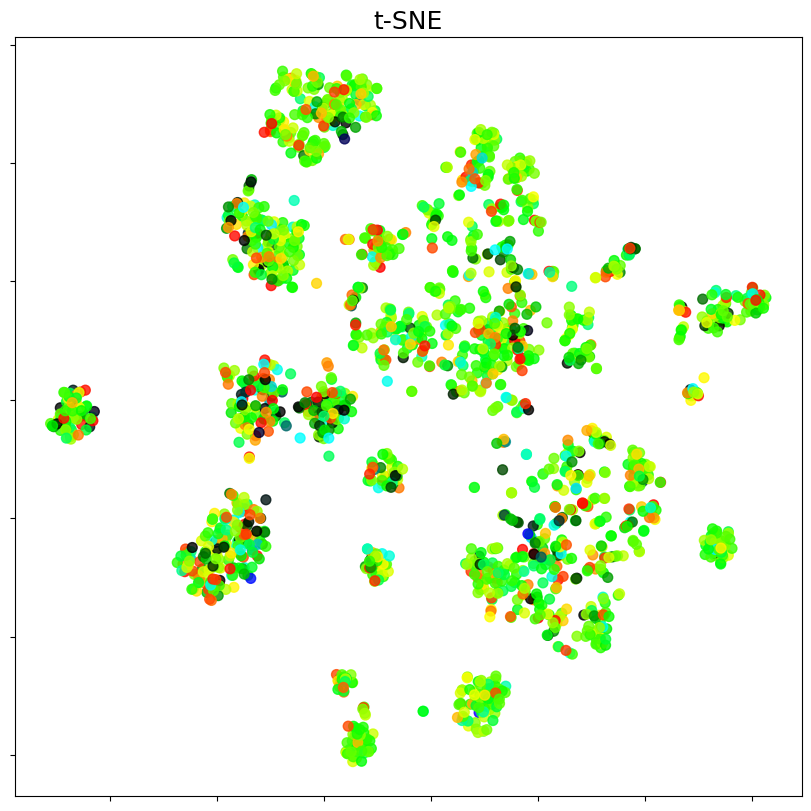

In [85]:

from matplotlib import ticker

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white", constrained_layout=True)
x, y = X_embedded.T
plt.title("t-SNE", fontdict={"fontsize":18})
ax.scatter(x, y, c=colorArr, s=50, alpha=0.8)
ax.xaxis.set_major_formatter(ticker.NullFormatter())
ax.yaxis.set_major_formatter(ticker.NullFormatter())
plt.show()